In [ ]:
!pip install langchain langchain-community langchain-core langchain-huggingface langchain-chroma langchain-groq langchain-tavily sentence-transformers chromadb pymupdf pypdf python-dotenv

In [ ]:
from dotenv import load_dotenv
from typing import List, TypedDict, Annotated, Sequence
from pydantic import BaseModel
import os

from langchain_core.documents import Document
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import create_retriever_tool
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_community.tools.tavily_search import TavilySearchResults

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

In [ ]:
load_dotenv()

True

In [ ]:
GROQ_API_KEY = os.environ["GROQ_API_KEY"]
if GROQ_API_KEY is None:
  raise ValueError("GROQ_API_KEY is not set")

In [ ]:
embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    api_key=GROQ_API_KEY
)

In [ ]:
DATA_PATH_1="/content/drive/MyDrive/RAG_Article/data1"
DATA_PATH_2="/content/drive/MyDrive/RAG_Article/data2"

In [ ]:
documents_1 = []

for file in os.listdir(DATA_PATH_1):
    if file.endswith(".pdf"):
        loader = PyMuPDFLoader(os.path.join(DATA_PATH_1, file))
        documents_1.extend(loader.load())

print(f"Loaded {len(documents_1)} pages.")

documents_2 = []

for file in os.listdir(DATA_PATH_2):
    if file.endswith(".pdf"):
        loader = PyMuPDFLoader(os.path.join(DATA_PATH_2, file))
        documents_2.extend(loader.load())

print(f"Loaded {len(documents_2)} pages.")

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks_1 = text_splitter.split_documents(documents_1)

print(f"Total chunks: {len(chunks_1)}")

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks_2 = text_splitter.split_documents(documents_2)

print(f"Total chunks: {len(chunks_2)}")

In [ ]:
# ChromaDB Path
CHROMA_DB_DIR_1 = "/content/drive/MyDrive/RAG_Article/chroma_db1"
CHROMA_DB_DIR_2 = "/content/drive/MyDrive/RAG_Article/chroma_db2"

In [ ]:
vector_store_1 = Chroma.from_documents(
    documents=chunks_1,
    embedding=embedding_model,
    persist_directory=CHROMA_DB_DIR_1
)

retriever_1 = vector_store_1.as_retriever(search_type='similarity', search_kwargs={'k':4})

vector_store_2 = Chroma.from_documents(
    documents=chunks_2,
    embedding=embedding_model,
    persist_directory=CHROMA_DB_DIR_2
)

retriever_2 = vector_store_2.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [ ]:
retrieval_tool_1 = create_retriever_tool(
    retriever_1,
    name="api_gateway_incident_search",
    description="Use this tool to find information specific to the Orion API Gateway performance investigation and incident report from January 2025."
)

retrieval_tool_2 = create_retriever_tool(
    retriever_2,
    name="andes_travel_journal_search",
    description="Use this tool to find information specific to Eleanor Whitmore's 1898 Andes expedition journal, including daily logs, local traditions, and high-altitude geographical observations."
)

web_search_tool = TavilySearchResults(
    max_results=5,
    topic="general",
    description=(
      "Use this tool ONLY when the user's question cannot be answered "
      "from the API gateway incident report or the Andes travel journal, "
      "e.g. general knowledge, current events, or anything outside those "
      "two document sources."
    )
)

tools = [retrieval_tool_1, retrieval_tool_2, web_search_tool]

In [ ]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [ ]:
llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = """You are a helpful assistant with access to three tools:

1. api_gateway_incident_search - for questions about the Orion API Gateway
   incident investigation (Jan 2025).
2. andes_travel_journal_search - for questions about Eleanor Whitmore's 1898
   Andes expedition journal.
3. web_search - for anything else, e.g. general knowledge or current events
   not covered by the two document sources.

Rules:
- Always prefer a retrieval tool over web_search when the question relates
  to the API gateway incident or the Andes journal.
- You may call more than one tool, and more than once, if the question
  requires it (e.g. comparing information from both documents).
- If the retrieved context is insufficient to answer confidently, say so
  rather than making things up.
- Always cite which source (document name / tool) an answer came from.
"""

In [ ]:
def agent_node(state: AgentState):
    """Decide whether to call a tool or answer directly."""
    messages = state["messages"]
    if not any(isinstance(m, SystemMessage) for m in messages):
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + list(messages)
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

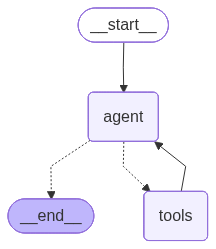

In [ ]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge(START, "agent")

# tools_condition inspects the last AIMessage: if it contains tool_calls,
# route to "tools"; otherwise route to END.
graph_builder.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)

graph_builder.add_edge("tools", "agent")

app = graph_builder.compile()
app

In [ ]:
inputs = {
    "messages": [
        HumanMessage(content="give me some recent AI News")
    ]
}

for event in app.stream(inputs, stream_mode="updates"):
    print("=" * 80)

    for node_name, output in event.items():

        print(f"NODE: {node_name}")

        if "messages" in output:
            for message in output["messages"]:
                message.pretty_print()

NODE: agent
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_91188be6-1219-448b-8ad4-68ed135f6f1c)
 Call ID: fc_91188be6-1219-448b-8ad4-68ed135f6f1c
  Args:
    query: latest AI news July 2026
NODE: tools
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Future Tools - AI News", "url": "https://futuretools.io/news", "content": "## Thursday, July 2, 2026\n\nAnthropic Details Fable 5 Cyber Safeguards and Jailbreak Severity Framework\n\nanthropic.com\n\nAnthropic has detailed the cybersecurity safeguards and a new jailbreak severity framework for Claude Fable 5, now globally available. The model uses safety classifiers that sort requests into four categories: prohibited use, high-risk dual use, low-risk dual use, and benign use. Fable 5's safety margin is set larger than previous models. Anthropic also proposes a jailbreak severity frame